# Description

Notebook to create a sin based dataset

In [1]:
import os
import sys

CURRENT_DIR = os.getcwd()
FOLDERS = CURRENT_DIR.split(os.sep)
TESIS_FOLDER_INDEX = FOLDERS.index('Tesis')
CURRENT_DIR = os.sep.join(FOLDERS[:TESIS_FOLDER_INDEX+1])
CURRENT_DIR = os.path.join(CURRENT_DIR, 'noise_reduction')
LIBS_PATH = os.path.join(CURRENT_DIR, 'src', 'libs')
assert os.path.exists(LIBS_PATH)
sys.path.append(LIBS_PATH)

In [2]:
import numpy as np
import pandas as pd
import pmdarima as pm
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
import torch
import random
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable

# Locals
from utils import *
from dataset import BioFuelDataset
from models import *
import config as cfg

In [3]:
DATA_PATH = os.path.join(CURRENT_DIR, 'data')
CHECKPOINT_PATH = os.path.join(CURRENT_DIR, 'checkpoints')
CONFIG_PATH = os.path.join(CURRENT_DIR, 'config')

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
assert device.type == "cuda"

In [5]:
def sin_function(x):
    """
    Function that takes in a value x and returns its sin.
    The values are scaled to be between 0 and 1.

    Args:
        x (float): value to be transformed.

    Returns:
        float: value of sin(x) scaled to be between 0 and 1.
    """

    return (1 + np.sin(np.pi * x))/2


def polinomial_function(x):
    """
    Function that takes in a value x and returns its polinomial value.

    Args:
        x (float): value to be transformed.

    Returns:
        float: result of the polinomial function.
    """

    return x**4 -x**3 -20*(x**2) -20*x +6


def generate_data(num_points, degree, noise=0.1):
    x = np.random.uniform(-1, 1, num_points)
    y_true = np.polyval(np.random.rand(degree + 1), x)
    y_noisy = y_true #+ noise * np.random.randn(num_points)
    return x, y_noisy


def add_gaussian_noise(df, columns, mean=0, std=0.1):
    """
    Adds Gaussian noise to specified columns in a DataFrame.

    Args:
        df (pandas.DataFrame): The DataFrame to which noise will be added.
        columns (list): A list of column names in the DataFrame to which noise will be added.
        mean (int, optional): The mean of the Gaussian distribution. Defaults to 0.
        std (float, optional): The standard deviation of the Gaussian distribution. Defaults to 0.1.

    Returns:
        pandas.DataFrame: The DataFrame with added Gaussian noise to specified columns.
    """
    for col in columns:
        df[col] = df[col] + np.random.normal(loc=mean, scale=std, size=len(df))
    return df


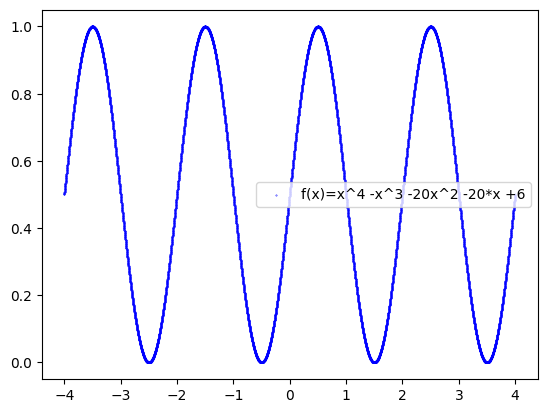

In [6]:
X_train = np.linspace(-4, 4, 10001)
y_train = sin_function(X_train)

# X_train = np.linspace(-5, 2, 1001)
# y_train = polinomial_function(X_train)

# X, y = generate_data(101, 3)

df_train = pd.DataFrame({'X': X_train, 'y': y_train})
plt.scatter(df_train['X'], df_train['y'], color='b', s=0.1)
plt.legend(['f(x)=x^4 -x^3 -20x^2 -20*x +6'])

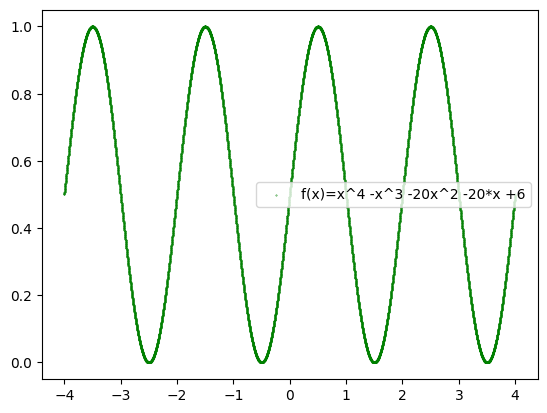

In [61]:
X_val = np.linspace(-4, 4, 10001)
y_val = sin_function(X_val)

# X_val = np.linspace(2, 4.5, 101)
# y_val = polinomial_function(X_val)

df_val = pd.DataFrame({'X': X_val, 'y': y_val})
plt.scatter(df_val['X'], df_val['y'], color='g', s=0.1)
plt.legend(['f(x)=x^4 -x^3 -20x^2 -20*x +6'])

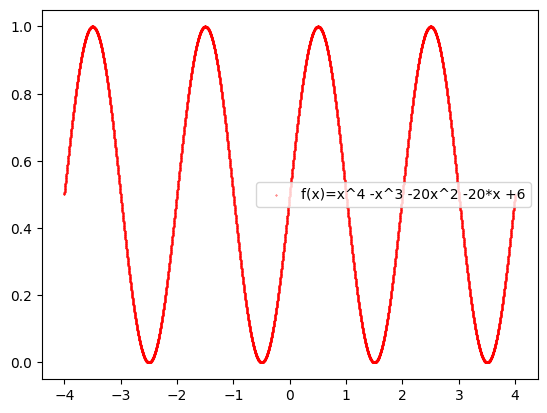

In [62]:
X_test = np.linspace(-4, 4, 10001)
y_test = sin_function(X_test)

# X_test = np.linspace(4.5, 8, 101)
# y_test = polinomial_function(X_test)


df_test = pd.DataFrame({'X': X_test, 'y': y_test})
plt.scatter(df_test['X'], df_test['y'], color='r', s=0.1)
plt.legend(['f(x)=x^4 -x^3 -20x^2 -20*x +6'])

In [63]:
sigma = 0.1
df_noisy = add_gaussian_noise(
        df=df_train.copy(),
        columns=[x for x in df_train.columns],
        mean=0,
        std=sigma
)

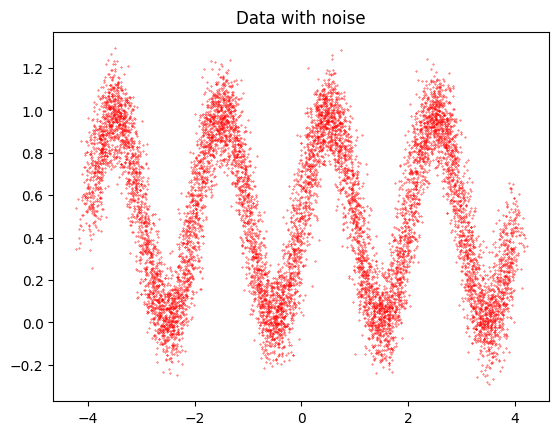

In [64]:
plt.title('Data with noise')
plt.scatter(df_noisy['X'], df_noisy['y'], color='r', s=0.1)

In [65]:
scaler = MinMaxScaler()
df_noisy = pd.DataFrame(scaler.fit_transform(df_noisy))
df_noisy.columns = ['X', 'y']

In [66]:
df_val = pd.DataFrame(scaler.transform(df_val))
df_val.columns = ['X', 'y']
df_val.describe().T

,count,mean,std,min,25%,50%,75%,max
X,10001.0,0.500295,0.273246,0.027090,0.263693,0.500295,0.736898,0.973501
y,10001.0,0.499949,0.223086,0.184458,0.277144,0.499949,0.722755,0.815441


In [67]:
df_test = pd.DataFrame(scaler.transform(df_test))
df_test.columns = ['X', 'y']
df_test.describe().T

,count,mean,std,min,25%,50%,75%,max
X,10001.0,0.500295,0.273246,0.027090,0.263693,0.500295,0.736898,0.973501
y,10001.0,0.499949,0.223086,0.184458,0.277144,0.499949,0.722755,0.815441


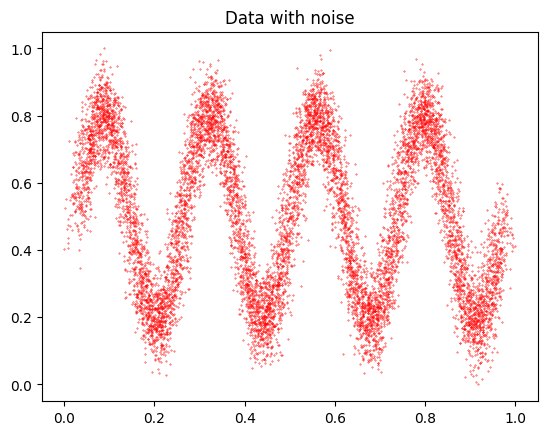

In [68]:
plt.title('Data with noise')
plt.scatter(df_noisy['X'], df_noisy['y'], color='r', s=0.1)

In [69]:
# _X_train, X_test, _y_train, y_test = train_test_split(
#     df_noisy['X'], df_noisy['y'], 
#     test_size=0.2, 
#     shuffle=False
# )
# X_train, X_val, y_train, y_val = train_test_split(
#     _X_train, _y_train, 
#     test_size=0.15, 
#     shuffle=False
# )

# # unsorted_train_indexes = X_train.index.tolist()
# # random.shuffle(unsorted_train_indexes)
# # unsorted_val_indexes = X_val.index.tolist()
# # random.shuffle(unsorted_val_indexes)
# # unsorted_test_indexes = X_test.index.tolist()
# # random.shuffle(unsorted_test_indexes)

# # X_train = X_train[unsorted_train_indexes]
# # y_train = y_train[unsorted_train_indexes]
# # X_val = X_val[unsorted_val_indexes]
# # y_val = y_val[unsorted_val_indexes]
# # X_test = X_test[unsorted_test_indexes]
# # y_test = y_test[unsorted_test_indexes]

# Transform the data into a tensor
bio_dataset_train = BioFuelDataset(
    input_df=df_noisy['X'],
    target_df=df_noisy['y']
)
# Transform the data into a tensor
bio_dataset_val = BioFuelDataset(
    input_df=df_val['X'],
    target_df=df_val['y']
)

# Create the dataloaders
batch_size = 64
train_dataloader = DataLoader(bio_dataset_train, batch_size=batch_size, shuffle=True, num_workers=0)
val_dataloader = DataLoader(bio_dataset_val, batch_size=batch_size, shuffle=True, num_workers=0)

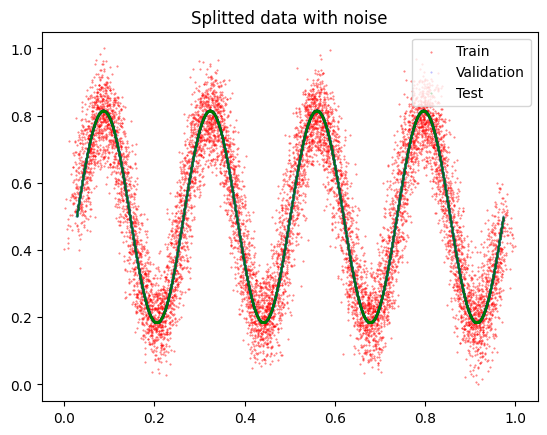

In [70]:
plt.title('Splitted data with noise')
plt.scatter(df_noisy['X'], df_noisy['y'], color='r', s=0.2, alpha=0.6)
plt.scatter(df_val['X'], df_val['y'], color='b', s=0.2, alpha=0.3)
plt.scatter(df_test['X'], df_test['y'], color='g', s=0.2, alpha=0.3)
plt.legend(['Train', 'Validation', 'Test'])

In [40]:
# class NeuralNetwork(nn.Module):
#     def __init__(self, input_dim, hidden_dim, output_dim):
#         super(NeuralNetwork, self).__init__()
#         self.model = nn.Sequential()
#         self.model.add_module('linear_0', nn.Linear(input_dim, hidden_dim))
#         self.model.add_module('activation_0', nn.ReLU())
#         self.model.add_module('linear_1', nn.Linear(hidden_dim, output_dim))
#         # self.fc1 = nn.Linear(input_dim, hidden_dim)
#         # self.relu = nn.ReLU()
#         # self.fc2 = nn.Linear(hidden_dim, output_dim)

#     def forward(self, x):
#         # x = self.fc1(x)
#         # x = self.relu(x)
#         # x = self.fc2(x)
#         return self.model(x)

# model = NeuralNetwork(1, 16, 1)
# model.to(device)

In [18]:
model = GridFullyDenseNN(
    n_layers=2,
    hidden_layers=[
        (1, 1024),
        (1024, 1),
    ],
    dropout_layers=[
        0.0,
        0.0,
    ],
    activation_func_layers=[
        nn.ReLU(),
        nn.Identity(),
    ],
    want_dropout=[
        False,
        False,
    ],
    want_linear=[
        True,
        True,
    ],
    want_activation=[
        True,
        False,
    ],
)
model.to(device)

GridFullyDenseNN(
  (model): Sequential(
    (linear_0): Linear(in_features=1, out_features=1024, bias=True)
    (activation_0): ReLU()
    (linear_1): Linear(in_features=1024, out_features=1, bias=True)
  )
)

In [19]:
lr = 0.001
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

# Define the trainer
trainer_basic = Trainer(
    model=model,
    train_generator=train_dataloader,
    val_generator=val_dataloader,
    device=device,
    criterion=criterion,
    optimizer=optimizer,
    epoch_scheduler=None,
    batch_scheduler=None,
    patience=15,
    epochs=500,
    checkpoints_path=os.path.join(CHECKPOINT_PATH, f'model_sin_noise_{0.2}.pt'),
)

In [20]:
model, train_losses, val_losses, best_train_loss, best_val_loss = trainer_basic.fit(verbose=True)

Training is started!


Epochs loop:  22%|▏| 109/500 [02:15<08:04,  1.24s/epoch, Train loss: 0.

Training stopped as validation loss did not improve for 15 epochs.


In [71]:
y_pred_test = model(torch.tensor(df_test['X'].values.reshape(-1, 1)).float().to(device)).cpu().detach().numpy().reshape(-1)

In [72]:
y_pred_val = model(torch.tensor(df_val['X'].values.reshape(-1, 1)).float().to(device)).cpu().detach().numpy().reshape(-1)

In [73]:
y_pred_train = model(torch.tensor(df_noisy['X'].values.reshape(-1, 1)).float().to(device)).cpu().detach().numpy().reshape(-1)

In [74]:
mae = mean_absolute_error(df_test['y'].values, y_pred_test)
mse = mean_squared_error(df_test['y'].values, y_pred_test)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((df_test['y'].values - y_pred_test) / df_test['y'].values)) * 100
r_squared = r2_score(df_test['y'].values, y_pred_test)
print("MAE: ", mae)
print("MAPE: ", mape)
print("RMSE: ", rmse)
print("MSE: ", mse)
print("R-squared: ", r_squared)

MAE:  0.03858292895074226
MAPE:  8.318187742910736
RMSE:  0.04686309600010772
MSE:  0.002196149766715312
R-squared:  0.9558672935731714


In [75]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
X,10001.0,0.0,2.309747,-4.0,-2.000000,0.0,2.000000,4.0
y,10001.0,0.5,0.353553,0.0,0.146891,0.5,0.853109,1.0


In [76]:
df_val.describe().T

,count,mean,std,min,25%,50%,75%,max
X,10001.0,0.500295,0.273246,0.027090,0.263693,0.500295,0.736898,0.973501
y,10001.0,0.499949,0.223086,0.184458,0.277144,0.499949,0.722755,0.815441


In [77]:
df_test.describe().T

,count,mean,std,min,25%,50%,75%,max
X,10001.0,0.500295,0.273246,0.027090,0.263693,0.500295,0.736898,0.973501
y,10001.0,0.499949,0.223086,0.184458,0.277144,0.499949,0.722755,0.815441


In [78]:
df_noisy.describe().T

,count,mean,std,min,25%,50%,75%,max
X,10001.0,0.500558,0.273564,0.0,0.263703,0.499109,0.736900,1.0
y,10001.0,0.499390,0.232488,0.0,0.283906,0.502057,0.712889,1.0


In [79]:
y_pred_val

array([0.570474  , 0.57089627, 0.57131857, ..., 0.36293024, 0.3632005 ,
       0.36347085], dtype=float32)

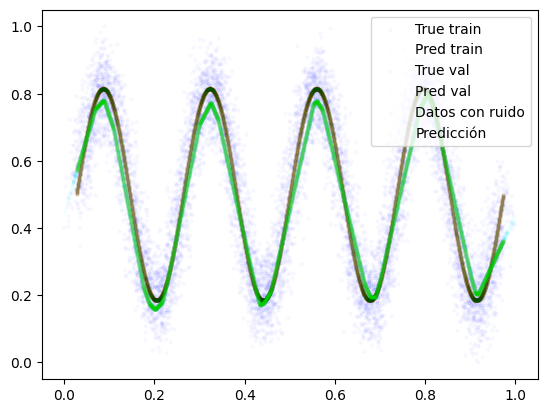

In [80]:
plt.scatter(df_noisy['X'].values, df_noisy['y'].values, color='b', label='True train', s=5, alpha=0.02)
plt.scatter(df_noisy['X'].values, y_pred_train, color='cyan', label='Pred train', s=5, alpha=0.02)
plt.scatter(df_val['X'].values, df_val['y'].values, color='r', label='True val', s=5, alpha=0.02)
plt.scatter(df_val['X'].values, y_pred_val, color='pink', label='Pred val', s=5, alpha=0.02)
plt.scatter(df_test['X'].values, df_test['y'].values, color='g', label='Datos con ruido', s=5, alpha=0.02)
plt.scatter(df_test['X'].values, y_pred_test, color='lime', label='Predicción', s=5, alpha=0.02)
plt.legend()
plt.show()